In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model='gpt-4o')

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

search_tool.invoke("Obama's first name?")

"Barack HusseinObamaII was born on August 4, 1961 [3] in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. [4][5] He is thefirstPresident to have been born in Hawaii. [6] His father was a black exchange student from Kenya named BarackObamaSr. He died in a motorcycle accident in Kenya in 1982. His mother ... BarackObama, the 44th President of the United States, is no exception. While hisnameis widely recognized today, there's a fascinating story behind it, including questions about whether he ever changed hisnameor used a different one before rising to prominence. Understanding the origins of BarackObama'snamesheds light on his multicultural background and the diverse influences that ... BarackObama, the 44th President of the United States, broke barriers as thefirstAfrican-American president and implemented significant healthcare reforms during his tenure. Learn about BarackObama'sancestry. His African r

In [4]:
from langchain_google_community import GmailToolkit

toolkit = GmailToolkit()

In [5]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

C:\Users\soobi\AppData\Local\Temp\ipykernel_28748\565237025.py:10: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\soobi\AppData\Local\Temp\ipykernel_28748\565237025.py:15: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
gmail_tool_list = gmail_toolkit.get_tools()

In [7]:
import inspect
from langchain_google_community.gmail.utils import get_gmail_credentials

# 함수가 받는 실제 인자 리스트를 출력합니다.
print(inspect.signature(get_gmail_credentials))

(token_file: 'Optional[str]' = None, client_sercret_file: 'Optional[str]' = None, service_account_file: 'Optional[str]' = None, scopes: 'Optional[List[str]]' = None, use_domain_wide: 'bool' = False, delegated_user: 'Optional[str]' = None) -> 'Credentials'


In [8]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b


In [ ]:

from langchain_openai import OpenAIEmbeddings
import dotenv 
from langchain_pinecone import PineconeVectorStore


dotenv.load_dotenv()
index_name = "real-estate-tax"
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vectorstore = PineconeVectorStore(index_name=index_name, embedding=embeddings)

retriever = vectorstore.as_retriever(search_kwargs={"k": 8})

C:\Users\soobi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:

import operator
from typing import Annotated, List, Union
# 리트리버된 응답 메시지 상태객체생성


from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState

class response_state(MessagesState):
    #MessagesState 객체에서 LLM이 답변한 메시지를 가져와야 합니다.
    context: Annotated[List[str], operator.add] # 리트리버된 문서 리스트를 담을 공간

    

    

In [ ]:
from langchain.tools import tool
import asyncio

@tool
async def retrieve_parallel_context(state: response_state):
    """
    [사용 지침]
    1. 정보가 부족하면 최대 2~3개의 핵심 쿼리로 분할하여 병렬 검색을 수행하세요.
    2. 검색 결과에서 숫자가 포함된 세부 조항이나 법적 근거는 누락 없이 모두 나열해야 합니다.
    """
    query = state["messages"][0].content  # 첫 번째 메시지를 질문으로 간주
    tasks=[ vectorstore.asimilarity_search(query, k=8)]


    results = await asyncio.gather(*tasks)

  
    flat_docs = []
    for doc_list in results:
        flat_docs.extend(doc_list)

    
   
    
    return {'messages' : flat_docs}

In [12]:
from langgraph.prebuilt import ToolNode


tool_list = [add, multiply, search_tool, retrieve_parallel_context ] + gmail_tool_list 
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [13]:
tool_list

[StructuredTool(name='add', description='Add two numbers together.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x00000282C28BBD80>),
 StructuredTool(name='multiply', description='Multiply two numbers together.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x00000282C28BACA0>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 <function __main__.retrieve_parallel_context(state: __main__.response_state)>,
 GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x00000282C29911F0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000282C29911F0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x00000282C29911F0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x00000282C29911F0>),
 GmailGetThre

In [14]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [15]:
def retrieve_agent(state: MessagesState):
    system_prompt = """[역할] 대한민국 종합부동산세(종부세) 계산 및 법령 해석 전문가 도구입니다.
    1. 도구 사용 시, 각 도구의 역할과 기능을 명확히 이해하고 활용하세요.
    3. 도구를 사용하여 얻은 정보를 바탕으로 질문에 대한 최종 답변을 생성하세요.
    4. 도구 사용 후에는 반드시 최종 답변을 생성하여 사용자에게 제공하세요.
    """
    response = state['messages'] + [system_prompt]
    response = llm_with_tools.invoke(response)
    
   
    
    return {"messages": [response]}

In [16]:
def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return 'end'


In [17]:
graph_builder.add_node('retrieve_agent', retrieve_agent)
graph_builder.add_node('tools', tool_node)



In [18]:
from langgraph.graph import START , END


graph_builder.add_edge(START, 'retrieve_agent')

graph_builder.add_conditional_edges('retrieve_agent', should_continue,
 {'tools': 'tools',
 'end': END
 })
 
graph_builder.add_edge('tools','retrieve_agent')



In [19]:
graph = graph_builder.compile()

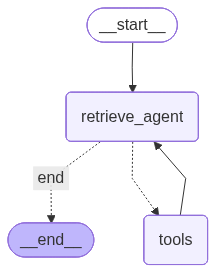

In [20]:
from IPython.display  import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
from langchain_core.messages import HumanMessage

query = '15억짜리 집 1개있을때 종합부동산세를 계산해주세요'

# stream() -> astream() 으로 변경하고 앞에 await를 붙입니다.
async for chunk in graph.astream({"messages": [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

15억짜리 집 1개있을때 종합부동산세를 계산해주세요
================================== Ai Message ==================================
Tool Calls:
  retrieve_parallel_context (call_1MnepvGt0INc0yfmgVc7Rlss)
 Call ID: call_1MnepvGt0INc0yfmgVc7Rlss
  Args:
    state: {'messages': [{'content': '15억짜리 집 1개있을때 종합부동산세를 계산해주세요', 'type': 'human'}], 'context': []}
    context: ['- 종합부동산세(종부세)는 각 연도별 주택 및 토지의 공시가격을 기준으로 계산됩니다.', '- 주택에 대한 종부세 계산은 기본세율과 과세표준에 따라 달라지며, 기본공제를 받은 후 남은 금액에 대해 세율을 곱하여 계산됩니다.', '- 2023년 기준, 종부세 과세표준은 주택의 공시가격이 6억 원을 초과할 때 발생합니다.', '- 세율은 과세표준 구간에 따라 0.6%부터 3%까지 다양하게 적용됩니다.', '- 1세대 1주택자의 경우, 추가 공제 혜택이 있을 수 있으며, 이는 지역별 및 주택 가격에 따라 달라질 수 있습니다.', '- 최신 법령 기준의 종부세 세율 및 공제 기준을 확인해야 합니다.']
================================= Tool Message =================================
Name: retrieve_parallel_context

{'messages': [Document(id='3282ce2e-f6ce-4ebd-b5c3-df4c41aee528', metadata={'source': 'output_real_estate_tax.txt'}, pa